# Benchmark czasu inferencji modeli — wersja naprawiona

Ten notebook mierzy czas inferencji trzech modeli:

- CNN na surowych oknach I/Q,
- Random Forest na cechach `.parquet`,
- XGBoost na cechach `.parquet`.

Wynikiem są tabele i wykresy: `ms/window`, `windows/s` oraz przybliżony `real-time factor`.

Notebook jest samowystarczalny: definiuje ścieżki, wczytuje modele, próbuje odtworzyć `X_test` z plików `.parquet`, a jeśli to się nie uda, tworzy syntetyczne dane o poprawnej liczbie cech do pomiaru samego czasu predykcji.


In [1]:
from pathlib import Path
import json
import time
import warnings
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/workspace/gps-spoofing")
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = PROJECT_DIR / "figures"
FEATURES_DIR = PROJECT_DIR / "features"

MODELS_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

SAMPLE_RATE = 50_000_000
DEFAULT_WINDOW_SAMPLES = 131_072
RANDOM_STATE = 42

print("PROJECT_DIR:", PROJECT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("FEATURES_DIR:", FEATURES_DIR)


PROJECT_DIR: /workspace/gps-spoofing
MODELS_DIR: /workspace/gps-spoofing/models
REPORTS_DIR: /workspace/gps-spoofing/reports
FIGURES_DIR: /workspace/gps-spoofing/figures
FEATURES_DIR: /workspace/gps-spoofing/features


## 1. Ścieżki artefaktów

Jeżeli zmieniłeś nazwy plików modeli, popraw je tylko w słowniku `ARTIFACTS` poniżej.

In [2]:
ARTIFACTS = {
    "cnn": {
        "model_path": MODELS_DIR / "cnn_raw_iq_tuni2025_v6_clean_timesplit_torchscript.pt",
        "config_path": REPORTS_DIR / "cnn_raw_iq_tuni2025_v6_clean_timesplit_config.json",
        "metrics_path": REPORTS_DIR / "cnn_raw_iq_tuni2025_v6_clean_timesplit_metrics.json",
        "pred_path": REPORTS_DIR / "cnn_raw_iq_tuni2025_v6_clean_timesplit_test_predictions.csv",
    },
    "rf": {
        "model_path": MODELS_DIR / "random_forest_tuni2025_iq_features.joblib",
        "features_path": REPORTS_DIR / "random_forest_tuni2025_iq_features_feature_columns.json",
        "metrics_path": REPORTS_DIR / "random_forest_tuni2025_iq_features_metrics.json",
        "pred_path": REPORTS_DIR / "random_forest_tuni2025_iq_features_test_predictions.csv",
    },
    "xgb": {
        "model_path": MODELS_DIR / "xgboost_tuni2025_iq_features.joblib",
        "features_path": REPORTS_DIR / "xgboost_tuni2025_iq_features_feature_columns.json",
        "metrics_path": REPORTS_DIR / "xgboost_tuni2025_iq_features_metrics.json",
        "pred_path": REPORTS_DIR / "xgboost_tuni2025_iq_features_test_predictions.csv",
    },
}

for group, paths in ARTIFACTS.items():
    print("\n", group)
    for name, path in paths.items():
        print(f"  {name}: {path} | exists={path.exists()}")



 cnn
  model_path: /workspace/gps-spoofing/models/cnn_raw_iq_tuni2025_v6_clean_timesplit_torchscript.pt | exists=True
  config_path: /workspace/gps-spoofing/reports/cnn_raw_iq_tuni2025_v6_clean_timesplit_config.json | exists=True
  metrics_path: /workspace/gps-spoofing/reports/cnn_raw_iq_tuni2025_v6_clean_timesplit_metrics.json | exists=True
  pred_path: /workspace/gps-spoofing/reports/cnn_raw_iq_tuni2025_v6_clean_timesplit_test_predictions.csv | exists=True

 rf
  model_path: /workspace/gps-spoofing/models/random_forest_tuni2025_iq_features.joblib | exists=True
  features_path: /workspace/gps-spoofing/reports/random_forest_tuni2025_iq_features_feature_columns.json | exists=True
  metrics_path: /workspace/gps-spoofing/reports/random_forest_tuni2025_iq_features_metrics.json | exists=True
  pred_path: /workspace/gps-spoofing/reports/random_forest_tuni2025_iq_features_test_predictions.csv | exists=True

 xgb
  model_path: /workspace/gps-spoofing/models/xgboost_tuni2025_iq_features.joblib

## 2. Funkcje pomocnicze

In [3]:
def load_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with open(path, "r") as f:
        return json.load(f)


def save_json(obj, path):
    path = Path(path)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def get_model_feature_columns(model, features_path=None):
    """Zwraca listę kolumn cech dla modelu tabelarycznego."""
    if features_path is not None:
        cols = load_json(features_path, default=None)
        if cols is not None:
            return list(cols)

    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)

    try:
        booster = model.get_booster()
        if booster.feature_names is not None:
            return list(booster.feature_names)
    except Exception:
        pass

    if hasattr(model, "n_features_in_"):
        return [f"f{i}" for i in range(int(model.n_features_in_))]

    raise ValueError("Nie da się ustalić liczby/nazw cech modelu.")


def get_prediction_count(pred_path, default=20_000):
    pred_path = Path(pred_path)
    if pred_path.exists():
        try:
            return len(pd.read_csv(pred_path))
        except Exception:
            return default
    return default


## 3. Wczytanie modeli

In [4]:
# Random Forest
assert ARTIFACTS["rf"]["model_path"].exists(), f"Brak modelu RF: {ARTIFACTS['rf']['model_path']}"
rf_model = joblib.load(ARTIFACTS["rf"]["model_path"])
rf_feature_columns = get_model_feature_columns(rf_model, ARTIFACTS["rf"]["features_path"])

# XGBoost
assert ARTIFACTS["xgb"]["model_path"].exists(), f"Brak modelu XGB: {ARTIFACTS['xgb']['model_path']}"
xgb_model = joblib.load(ARTIFACTS["xgb"]["model_path"])
xgb_feature_columns = get_model_feature_columns(xgb_model, ARTIFACTS["xgb"]["features_path"])

# CNN TorchScript
assert ARTIFACTS["cnn"]["model_path"].exists(), f"Brak modelu CNN TorchScript: {ARTIFACTS['cnn']['model_path']}"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = torch.jit.load(str(ARTIFACTS["cnn"]["model_path"]), map_location=device)
cnn_model.eval()

cnn_config = load_json(ARTIFACTS["cnn"]["config_path"], default={})
WINDOW_SAMPLES = int(cnn_config.get("WINDOW_SAMPLES", DEFAULT_WINDOW_SAMPLES))

print("Loaded RF:", type(rf_model), "features:", len(rf_feature_columns))
print("Loaded XGB:", type(xgb_model), "features:", len(xgb_feature_columns))
print("Loaded CNN TorchScript on", device)
print("WINDOW_SAMPLES:", WINDOW_SAMPLES)


Loaded RF: <class 'sklearn.ensemble._forest.RandomForestClassifier'> features: 25
Loaded XGB: <class 'xgboost.sklearn.XGBClassifier'> features: 24
Loaded CNN TorchScript on cuda
WINDOW_SAMPLES: 131072


## 4. Próba odtworzenia prawdziwego `X_test` z parquetów

Jeżeli pliki `.parquet` nie są dostępne albo kolumny nie pasują, notebook użyje syntetycznego `X_test`. Do benchmarku czasu inferencji wartości cech nie są kluczowe — ważna jest liczba wierszy i liczba cech.

In [5]:
ATTACK_INTERVALS_S = {"SS33": [(70.0, 150.0)]}
IGNORE_INTERVALS_S = {"SS33": [(65.0, 70.0), (150.0, 152.0)]}


def get_scenario_key(filename: str) -> str:
    name = str(filename).upper()
    m = re.search(r"(SS\d+)", name)
    if m:
        return m.group(1)
    m = re.search(r"(C\d+)", name)
    if m:
        return m.group(1)
    return "UNKNOWN"


def overlaps_interval(start_s, end_s, interval):
    a, b = interval
    return end_s > a and start_s < b


def label_from_scenario(scenario: str) -> int:
    return 1 if str(scenario).startswith("SS") else 0


def assign_temporal_label(row):
    scenario = row["scenario"]
    start_s = float(row["window_start_s"])
    end_s = float(row["window_end_s"])

    for interval in IGNORE_INTERVALS_S.get(scenario, []):
        if overlaps_interval(start_s, end_s, interval):
            return np.nan

    if scenario in ATTACK_INTERVALS_S:
        for interval in ATTACK_INTERVALS_S[scenario]:
            if overlaps_interval(start_s, end_s, interval):
                return 1
        return 0

    return label_from_scenario(scenario)


def add_estimated_time_columns(df):
    df = df.copy()

    start_cols = ["window_start_s", "start_s", "time_s", "t_start_s"]
    start_col = next((c for c in start_cols if c in df.columns), None)

    if start_col is not None:
        if start_col != "window_start_s":
            df["window_start_s"] = df[start_col]
        if "window_end_s" not in df.columns:
            df["window_end_s"] = df["window_start_s"]
        return df

    out = []
    for source_file, g in df.groupby("source_file", sort=False):
        g = g.copy()
        scenario = g["scenario"].iloc[0]
        duration_s = 200.0 if scenario == "SS33" else 150.0
        n = len(g)
        if n == 1:
            g["window_start_s"] = 0.0
            g["window_end_s"] = duration_s
        else:
            starts = np.linspace(0.0, duration_s, n, endpoint=False)
            step = duration_s / n
            g["window_start_s"] = starts
            g["window_end_s"] = starts + step
        out.append(g)

    return pd.concat(out, ignore_index=True)


def make_X(df, feature_columns):
    metadata_cols = [
        "label", "split", "source_file", "scenario",
        "window_start_s", "window_end_s", "window_idx", "file_idx",
        "row_id", "index", "time_s",
    ]
    drop_cols = [c for c in metadata_cols if c in df.columns]
    X = df.drop(columns=drop_cols)
    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    X = X.reindex(columns=feature_columns, fill_value=0)
    return X


def reconstruct_tuni2025_feature_test(feature_columns):
    parquet_files = sorted(FEATURES_DIR.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"Brak plików parquet w {FEATURES_DIR}")

    dfs = []
    for p in parquet_files:
        df = pd.read_parquet(p).copy()
        df["source_file"] = p.name
        df["scenario"] = get_scenario_key(p.name)
        dfs.append(df)

    all_df = pd.concat(dfs, ignore_index=True)
    all_df = add_estimated_time_columns(all_df)
    all_df["label"] = all_df.apply(assign_temporal_label, axis=1)
    all_df = all_df.dropna(subset=["label"]).copy()
    all_df["label"] = all_df["label"].astype(int)
    all_df = all_df[all_df["scenario"] != "C7"].copy()

    # Test = SS33
    test_df = all_df[all_df["scenario"] == "SS33"].copy()
    if len(test_df) == 0:
        raise ValueError("Nie znaleziono scenariusza SS33 w parquetach.")

    X = make_X(test_df, feature_columns)
    y = test_df["label"].astype(int).to_numpy()
    return X, y, test_df


## 5. Przygotowanie danych do benchmarku

In [6]:
# Liczba wierszy w fallbacku: próbujemy wziąć z zapisanych predykcji.
n_rows_fallback = max(
    get_prediction_count(ARTIFACTS["rf"]["pred_path"], default=20_000),
    get_prediction_count(ARTIFACTS["xgb"]["pred_path"], default=20_000),
)

try:
    X_test_rf, y_test_features, test_df_features = reconstruct_tuni2025_feature_test(rf_feature_columns)
    X_test_xgb = make_X(test_df_features, xgb_feature_columns)
    data_mode = "real parquet features"
except Exception as e:
    print("Nie udało się odtworzyć X_test z parquetów:", repr(e))
    print("Używam syntetycznego X_test do pomiaru czasu predict_proba.")
    rng = np.random.default_rng(RANDOM_STATE)
    X_test_rf = pd.DataFrame(
        rng.normal(size=(n_rows_fallback, len(rf_feature_columns))).astype(np.float32),
        columns=rf_feature_columns,
    )
    X_test_xgb = pd.DataFrame(
        rng.normal(size=(n_rows_fallback, len(xgb_feature_columns))).astype(np.float32),
        columns=xgb_feature_columns,
    )
    y_test_features = None
    test_df_features = None
    data_mode = "synthetic feature matrix"

print("Data mode:", data_mode)
print("X_test_rf:", X_test_rf.shape)
print("X_test_xgb:", X_test_xgb.shape)


Data mode: real parquet features
X_test_rf: (19301, 25)
X_test_xgb: (19301, 24)


## 6. Funkcje benchmarku

In [7]:
def benchmark_cnn_synthetic(model, device, n_windows, window_samples, batch_size=128, repeats=5):
    """Benchmark forward pass CNN na syntetycznych oknach I/Q."""
    model.eval()
    n_windows = int(n_windows)
    times = []

    # Jeden batch syntetyczny, wielokrotnie wykorzystywany.
    x_batch = torch.randn(batch_size, 2, window_samples, dtype=torch.float32, device=device)

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = torch.sigmoid(model(x_batch))
    if device.type == "cuda":
        torch.cuda.synchronize()

    for _ in range(repeats):
        done = 0
        start = time.perf_counter()
        with torch.no_grad():
            while done < n_windows:
                bs = min(batch_size, n_windows - done)
                if bs == batch_size:
                    xb = x_batch
                else:
                    xb = x_batch[:bs]
                _ = torch.sigmoid(model(xb))
                done += bs
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    elapsed = float(np.median(times))
    return {
        "model": "CNN raw I/Q",
        "input": "raw I/Q tensor",
        "n_windows": n_windows,
        "elapsed_s": elapsed,
        "ms_per_window": 1000 * elapsed / n_windows,
        "windows_per_second": n_windows / elapsed,
    }


def benchmark_tabular_model(model, X, model_name, input_name, repeats=5):
    n_windows = len(X)
    times = []

    # Warm-up
    _ = model.predict_proba(X.iloc[:min(1000, n_windows)])[:, 1]

    for _ in range(repeats):
        start = time.perf_counter()
        _ = model.predict_proba(X)[:, 1]
        times.append(time.perf_counter() - start)

    elapsed = float(np.median(times))
    return {
        "model": model_name,
        "input": input_name,
        "n_windows": n_windows,
        "elapsed_s": elapsed,
        "ms_per_window": 1000 * elapsed / n_windows,
        "windows_per_second": n_windows / elapsed,
    }


## 7. Uruchomienie benchmarku

In [8]:
N_WINDOWS_BENCH = max(len(X_test_rf), len(X_test_xgb), get_prediction_count(ARTIFACTS["cnn"]["pred_path"], default=20_000))

cnn_bench = benchmark_cnn_synthetic(
    model=cnn_model,
    device=device,
    n_windows=N_WINDOWS_BENCH,
    window_samples=WINDOW_SAMPLES,
    batch_size=128,
    repeats=5,
)

rf_bench = benchmark_tabular_model(
    model=rf_model,
    X=X_test_rf,
    model_name="Random Forest",
    input_name="cechy I/Q",
    repeats=5,
)

xgb_bench = benchmark_tabular_model(
    model=xgb_model,
    X=X_test_xgb,
    model_name="XGBoost",
    input_name="cechy I/Q",
    repeats=5,
)

bench_df = pd.DataFrame([cnn_bench, rf_bench, xgb_bench])

signal_seconds_per_window = WINDOW_SAMPLES / SAMPLE_RATE
bench_df["signal_ms_per_window_assumed"] = signal_seconds_per_window * 1000
bench_df["processed_signal_s_assumed"] = bench_df["n_windows"] * signal_seconds_per_window
bench_df["realtime_factor_assumed"] = bench_df["processed_signal_s_assumed"] / bench_df["elapsed_s"]
bench_df["data_mode"] = data_mode

bench_df = bench_df.sort_values("ms_per_window", ascending=True).reset_index(drop=True)
display(bench_df)

bench_df.to_csv(REPORTS_DIR / "models_inference_benchmark.csv", index=False)


,model,input,n_windows,elapsed_s,ms_per_window,windows_per_second,signal_ms_per_window_assumed,processed_signal_s_assumed,realtime_factor_assumed,data_mode
0,XGBoost,cechy I/Q,19301,0.004775,0.000247,4.042422e+06,2.62144,50.596413,10596.965701,real parquet features
1,Random Forest,cechy I/Q,19301,1.231796,0.063820,1.566899e+04,2.62144,50.596413,41.075322,real parquet features
2,CNN raw I/Q,raw I/Q tensor,19301,7.005341,0.362952,2.755184e+03,2.62144,50.596413,7.222549,real parquet features


## 8. Ładna tabela do raportu

In [9]:
bench_pretty_df = bench_df.copy()
bench_pretty_df["elapsed_s"] = bench_pretty_df["elapsed_s"].map(lambda x: f"{x:.4f}")
bench_pretty_df["ms_per_window"] = bench_pretty_df["ms_per_window"].map(lambda x: f"{x:.4f}")
bench_pretty_df["windows_per_second"] = bench_pretty_df["windows_per_second"].map(lambda x: f"{x:,.0f}")
bench_pretty_df["realtime_factor_assumed"] = bench_pretty_df["realtime_factor_assumed"].map(lambda x: f"{x:.1f}x")

cols = ["model", "input", "ms_per_window", "windows_per_second", "realtime_factor_assumed", "n_windows"]
display(bench_pretty_df[cols])
bench_pretty_df[cols].to_csv(REPORTS_DIR / "models_inference_benchmark_pretty.csv", index=False)


,model,input,ms_per_window,windows_per_second,realtime_factor_assumed,n_windows
0,XGBoost,cechy I/Q,0.0002,"4,042,422",10597.0x,19301
1,Random Forest,cechy I/Q,0.0638,"15,669",41.1x,19301
2,CNN raw I/Q,raw I/Q tensor,0.3630,"2,755",7.2x,19301


## 9. Wykresy

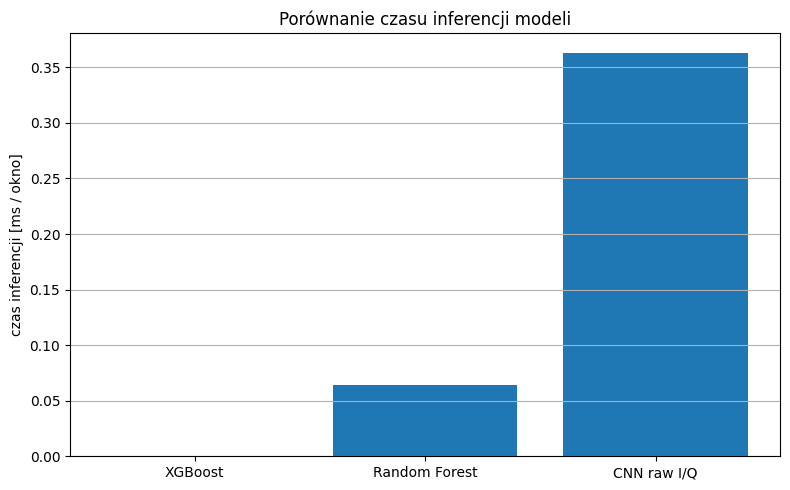

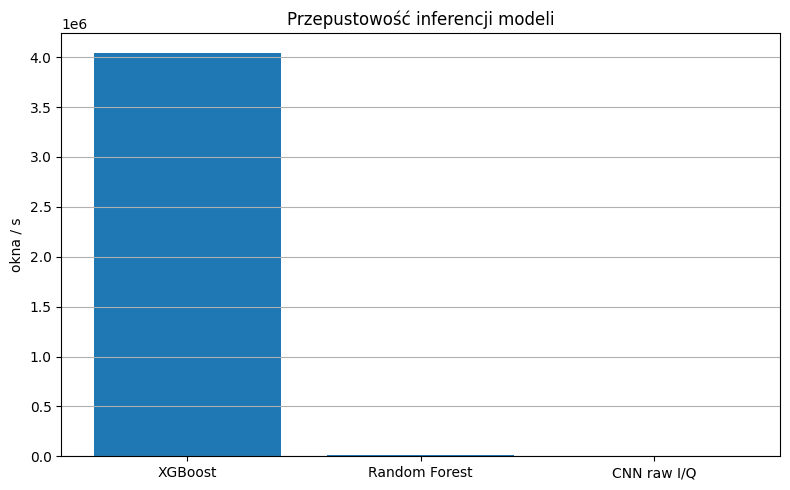

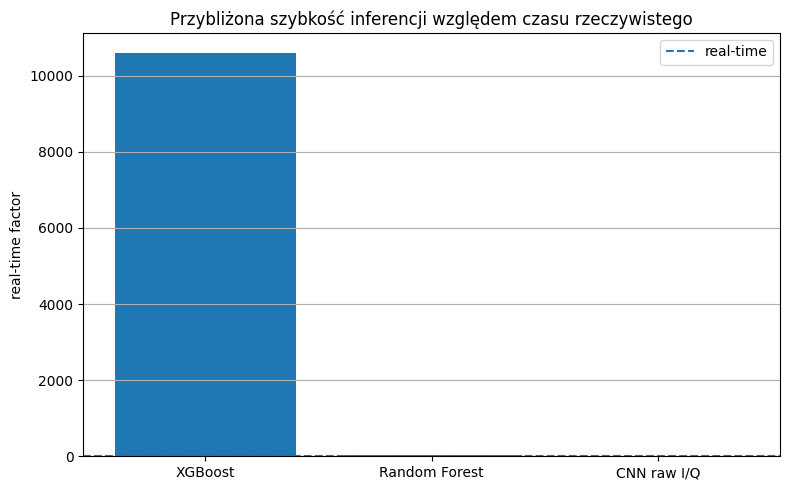

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(bench_df["model"], bench_df["ms_per_window"])
plt.ylabel("czas inferencji [ms / okno]")
plt.title("Porównanie czasu inferencji modeli")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "inference_time_ms_per_window.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(bench_df["model"], bench_df["windows_per_second"])
plt.ylabel("okna / s")
plt.title("Przepustowość inferencji modeli")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "inference_windows_per_second.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(bench_df["model"], bench_df["realtime_factor_assumed"])
plt.axhline(1.0, linestyle="--", linewidth=1.5, label="real-time")
plt.ylabel("real-time factor")
plt.title("Przybliżona szybkość inferencji względem czasu rzeczywistego")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "inference_realtime_factor.png", dpi=250)
plt.show()


## 10. Uwaga do raportu

Czas RF/XGBoost obejmuje tylko `predict_proba` na gotowych cechach. Nie obejmuje czasu ekstrakcji cech z surowego I/Q. Czas CNN obejmuje forward pass modelu na oknach I/Q, bez czytania `.bin` z dysku. To jest porównanie samej inferencji modeli, a nie pełnego pipeline'u end-to-end.